# EnergiFlow — Bloc 2 — Pipeline d'analyse complet

Étapes : extraction des 4 sources -> jointure en un dataset national unique -> visualisation des valeurs manquantes -> nettoyage -> standardisation (colonnes internes) -> analyse et visualisation en unités réelles.

Chaque étape est vérifiée avant de passer à la suivante (`.head()`, `.shape`, valeurs manquantes affichées).

## 0. Imports et connexion

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option('display.max_columns', None)

DB_USER, DB_PASSWORD = "energiflow", "energiflow"
DB_HOST, DB_PORT, DB_NAME = "localhost", "5433", "energiflow"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)
print("Connexion prête.")

Connexion prête.


## 1. Extraction — Source 1 : consommation nationale (`fact_consommation`)

In [2]:
df_conso = pd.read_sql(
    "SELECT start_date AS date_heure, value_mw AS consommation_mw "
    "FROM public.fact_consommation ORDER BY start_date;",
    engine, parse_dates=["date_heure"]
)
print(df_conso.shape)
df_conso.head()

(164666, 2)


,date_heure,consommation_mw
0,2024-12-31 23:00:00+00:00,57711.0
1,2024-12-31 23:00:00+00:00,61334.0
2,2024-12-31 23:00:00+00:00,63667.0
3,2024-12-31 23:00:00+00:00,64354.0
4,2024-12-31 23:15:00+00:00,57122.0


## 2. Extraction — Source 2 : météo (`fact_meteoid`)

Moyenne des 13 régions par heure, pour obtenir une température nationale au même grain que la consommation nationale.

In [3]:
df_meteo = pd.read_sql(
    "SELECT date_trunc('hour', date_heure) AS date_heure, "
    "       AVG(temperature_2m) AS temperature_c "
    "FROM public.fact_meteoid "
    "GROUP BY date_trunc('hour', date_heure) "
    "ORDER BY date_heure;",
    engine, parse_dates=["date_heure"]
)
print(df_meteo.shape)
df_meteo.head()

(13824, 2)


,date_heure,temperature_c
0,2025-01-01 00:00:00+00:00,3.061538
1,2025-01-01 01:00:00+00:00,3.184615
2,2025-01-01 02:00:00+00:00,3.338462
3,2025-01-01 03:00:00+00:00,3.469231
4,2025-01-01 04:00:00+00:00,3.661538


## 3. Extraction — Source 3 : prix de marché (`fact_prix_marche`)

Rappel : cette source ne couvre qu'une fenêtre glissante de quelques jours (limite structurelle de l'API RTE Wholesale Market, day-ahead uniquement — pas un problème de collecte). Le `.shape` ci-dessous le confirme visuellement.

In [4]:
df_prix = pd.read_sql(
    "SELECT date_heure, prix_eur_mwh FROM public.fact_prix_marche ORDER BY date_heure;",
    engine, parse_dates=["date_heure"]
)
print(df_prix.shape)
print("Période couverte :", df_prix['date_heure'].min(), "->", df_prix['date_heure'].max())
df_prix.head()

(384, 2)
Période couverte : 2026-07-27 22:00:00+00:00 -> 2026-07-31 21:45:00+00:00


,date_heure,prix_eur_mwh
0,2026-07-27 22:00:00+00:00,180.35
1,2026-07-27 22:15:00+00:00,170.61
2,2026-07-27 22:30:00+00:00,148.00
3,2026-07-27 22:45:00+00:00,138.00
4,2026-07-27 23:00:00+00:00,154.74


## 4. Extraction — Source 4 : consommation régionale (`fact_consommation_regionale`)

In [19]:
df_regions = pd.read_sql(
    "SELECT r.region, f.date_heure, f.consommation_brute_electricite_mw AS consommation_mw, "
    "       f.statut_rte "
    "FROM public.fact_consommation_regionale f "
    "JOIN public.dim_region r ON f.code_insee_region = r.code_insee_region "
    "WHERE f.statut_rte = 'Consolidé';",
    engine
)
print(df_regions.shape)
df_regions = df_regions.drop_duplicates(subset=["region", "date_heure"])
print(df_regions.shape)

(279312, 4)
(279312, 4)


## 5. Jointure — dataset national unique (grain horaire)

La consommation est au pas de 15 min ; on la ramène à l'heure pour matcher météo et prix (déjà horaires).

In [20]:
df_conso_h = (
    df_conso.set_index("date_heure")
    .resample("h")["consommation_mw"]
    .mean()
    .reset_index()
)

df_final = df_conso_h.merge(df_meteo, on="date_heure", how="left")
df_final = df_final.merge(df_prix, on="date_heure", how="left")

print(df_final.shape)
df_final.head()

(13775, 4)


,date_heure,consommation_mw,temperature_c,prix_eur_mwh
0,2024-12-31 23:00:00+00:00,62201.000000,NaN,NaN
1,2025-01-01 00:00:00+00:00,61102.071429,3.061538,NaN
2,2025-01-01 01:00:00+00:00,60292.714286,3.184615,NaN
3,2025-01-01 02:00:00+00:00,57524.857143,3.338462,NaN
4,2025-01-01 03:00:00+00:00,55415.785714,3.469231,NaN


## 6. Visualisation des valeurs manquantes

Avant tout nettoyage : combien de valeurs manquantes par colonne, et où elles se situent.

In [21]:
manquants = df_final.isna().sum()
pct_manquants = (manquants / len(df_final) * 100).round(1)
pd.DataFrame({"valeurs_manquantes": manquants, "pourcentage": pct_manquants})

,valeurs_manquantes,pourcentage
date_heure,0,0.0
consommation_mw,1921,13.9
temperature_c,1,0.0
prix_eur_mwh,13751,99.8


In [22]:
# Où se situent les trous de consommation dans le temps ?
trous = df_final[df_final["consommation_mw"].isna()]
print(trous["date_heure"].min(), "->", trous["date_heure"].max())
print(trous["date_heure"].dt.to_period("M").value_counts().sort_index())


2025-01-06 23:00:00+00:00 -> 2026-07-14 21:00:00+00:00
date_heure
2025-01     96
2025-02     96
2025-03     98
2025-04    118
2025-05     96
2025-06     98
2025-07    118
2025-08     96
2025-09    120
2025-10     97
2025-11     96
2025-12    120
2026-01     96
2026-02     96
2026-03    120
2026-04     96
2026-05     96
2026-06    120
2026-07     48
Freq: M, Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_24828\651860553.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(trous["date_heure"].dt.to_period("M").value_counts().sort_index())


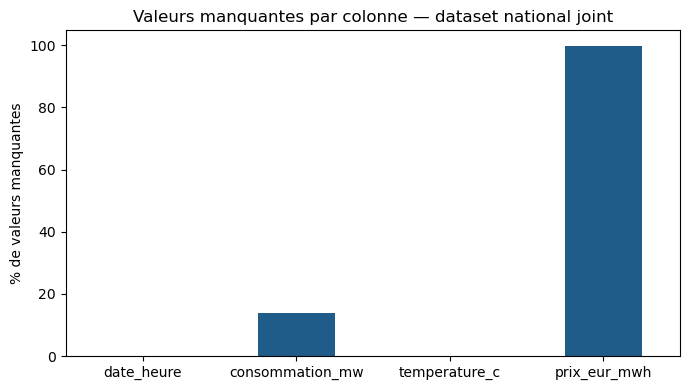

In [13]:
# Visualisation graphique des valeurs manquantes par colonne
plt.figure(figsize=(7, 4))
pct_manquants.plot(kind="bar", color="#1F5C8A")
plt.ylabel("% de valeurs manquantes")
plt.title("Valeurs manquantes par colonne — dataset national joint")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/valeurs_manquantes.png", dpi=150)
plt.show()

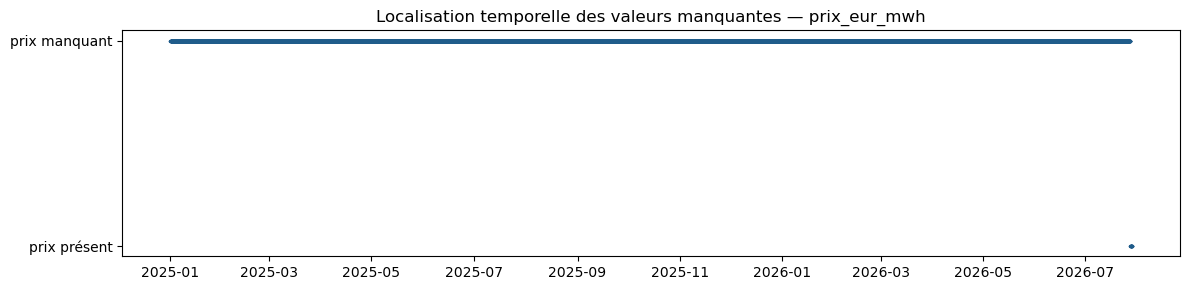

In [14]:
# Visualisation de la localisation temporelle des valeurs manquantes (le prix, surtout)
plt.figure(figsize=(12, 3))
plt.scatter(df_final["date_heure"], df_final["prix_eur_mwh"].isna().astype(int),
            s=2, color="#1F5C8A")
plt.yticks([0, 1], ["prix présent", "prix manquant"])
plt.title("Localisation temporelle des valeurs manquantes — prix_eur_mwh")
plt.tight_layout()
plt.savefig("figures/valeurs_manquantes_prix_temporel.png", dpi=150)
plt.show()

## 7. Nettoyage

Doublons supprimés. Les valeurs manquantes ne sont **pas comblées artificiellement** (surtout pas le prix — l'imputer inventerait des données qui n'existent pas) : elles restent documentées telles quelles.

In [23]:
avant = len(df_final)
df_final = df_final.drop_duplicates(subset="date_heure")
print(f"Lignes avant : {avant}, après suppression des doublons : {len(df_final)}")

trous_conso = df_final["consommation_mw"].isna().sum()
trous_meteo = df_final["temperature_c"].isna().sum()
print(f"Trous en consommation : {trous_conso}")
print(f"Trous en météo        : {trous_meteo}")
if trous_conso or trous_meteo:
    print("-> à examiner si non négligeable (panne de collecte ponctuelle).")

Lignes avant : 13775, après suppression des doublons : 13775
Trous en consommation : 1921
Trous en météo        : 1
-> à examiner si non négligeable (panne de collecte ponctuelle).


In [24]:
df_regions = df_regions.drop_duplicates()
print(df_regions.shape)

(279312, 4)


## 8. Standardisation (colonnes internes, en plus des unités réelles)

Deux colonnes z-score ajoutées pour les tests/comparaisons multi-échelles. **Les graphiques et le dashboard n'utiliseront que les colonnes en unités réelles** (MW, °C) — un dispatcheur a besoin de MW, pas de z-scores.

In [25]:
scaler = StandardScaler()
cols_a_standardiser = ["consommation_mw", "temperature_c"]
df_pour_scaling = df_final.dropna(subset=cols_a_standardiser)

z_scores = scaler.fit_transform(df_pour_scaling[cols_a_standardiser])
df_final.loc[df_pour_scaling.index, "consommation_mw_z"] = z_scores[:, 0]
df_final.loc[df_pour_scaling.index, "temperature_c_z"] = z_scores[:, 1]

df_final.head()

,date_heure,consommation_mw,temperature_c,prix_eur_mwh,consommation_mw_z,temperature_c_z
0,2024-12-31 23:00:00+00:00,62201.000000,NaN,NaN,NaN,NaN
1,2025-01-01 00:00:00+00:00,61102.071429,3.061538,NaN,1.090726,-1.444079
2,2025-01-01 01:00:00+00:00,60292.714286,3.184615,NaN,1.013192,-1.427682
3,2025-01-01 02:00:00+00:00,57524.857143,3.338462,NaN,0.748039,-1.407187
4,2025-01-01 03:00:00+00:00,55415.785714,3.469231,NaN,0.545996,-1.389766


In [ ]:
Matrice de corrélation complète (toutes les variables numériques)

In [26]:
# Matrice de corrélation entre toutes les variables réelles (hors z-scores, redondants)
cols_numeriques = ["consommation_mw", "temperature_c", "prix_eur_mwh"]
matrice_corr = df_final[cols_numeriques].corr()
matrice_corr

,consommation_mw,temperature_c,prix_eur_mwh
consommation_mw,1.000000,-0.558056,-0.413440
temperature_c,-0.558056,1.000000,-0.290156
prix_eur_mwh,-0.413440,-0.290156,1.000000


In [ ]:
Heatmap visuelle de cette matrice

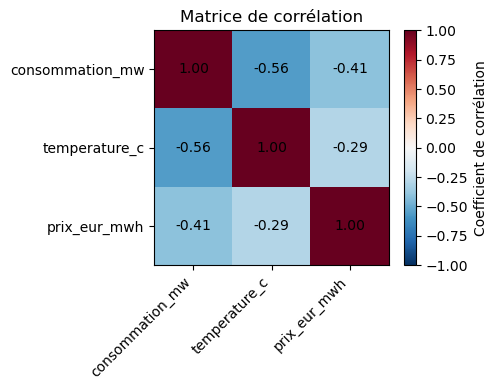

In [27]:
import numpy as np

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matrice_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_numeriques)))
ax.set_yticks(range(len(cols_numeriques)))
ax.set_xticklabels(cols_numeriques, rotation=45, ha="right")
ax.set_yticklabels(cols_numeriques)
for i in range(len(cols_numeriques)):
    for j in range(len(cols_numeriques)):
        val = matrice_corr.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")
plt.colorbar(im, label="Coefficient de corrélation")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("figures/matrice_correlation.png", dpi=150)
plt.show()

In [28]:
q1 = df_final["consommation_mw"].quantile(0.25)
q3 = df_final["consommation_mw"].quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

outliers = df_final[(df_final["consommation_mw"] < borne_basse) | (df_final["consommation_mw"] > borne_haute)]
print(f"Bornes IQR : [{borne_basse:.0f}, {borne_haute:.0f}] MW")
print(f"Valeurs aberrantes détectées : {len(outliers)} ({100*len(outliers)/len(df_final):.1f} %)")
outliers[["date_heure", "consommation_mw"]].sort_values("consommation_mw", ascending=False).head(10)

Bornes IQR : [20163, 78277] MW
Valeurs aberrantes détectées : 75 (0.5 %)


,date_heure,consommation_mw
8913,2026-01-07 08:00:00+00:00,88243.785714
8914,2026-01-07 09:00:00+00:00,88073.571429
8915,2026-01-07 10:00:00+00:00,87447.214286
8875,2026-01-05 18:00:00+00:00,87435.785714
8916,2026-01-07 11:00:00+00:00,87277.214286
8912,2026-01-07 07:00:00+00:00,87238.714286
8866,2026-01-05 09:00:00+00:00,86748.642857
8865,2026-01-05 08:00:00+00:00,86709.500000
8923,2026-01-07 18:00:00+00:00,86159.500000
8867,2026-01-05 10:00:00+00:00,86090.285714


In [29]:
profil_horaire = df_final.groupby("heure")["consommation_mw"].mean()

plt.figure(figsize=(9, 4))
profil_horaire.plot(marker="o", color="#1F5C8A")
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne (MW)")
plt.title("Profil horaire moyen de consommation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/profil_horaire.png", dpi=150)
plt.show()

KeyError: 'heure'

## 9. Sauvegarde du dataset nettoyé

In [30]:
df_final.to_csv("data/dataset_final_national.csv", index=False)
df_regions.to_csv("data/dataset_regional.csv", index=False)
print("Sauvegardé : data/dataset_final_national.csv, data/dataset_regional.csv")

Sauvegardé : data/dataset_final_national.csv, data/dataset_regional.csv


In [43]:
import pandas as pd

df = pd.read_csv("data/dataset_final_national.csv")
print(df.shape)
df.tail()

(13775, 6)


,date_heure,consommation_mw,temperature_c,prix_eur_mwh,consommation_mw_z,temperature_c_z
13770,2026-07-28 17:00:00+00:00,51107.285714,32.269231,144.39,0.133254,2.446931
13771,2026-07-28 18:00:00+00:00,49141.500000,31.869231,181.35,-0.055063,2.393644
13772,2026-07-28 19:00:00+00:00,47272.142857,30.407692,219.99,-0.234142,2.198940
13773,2026-07-28 20:00:00+00:00,47715.000000,28.384615,210.79,-0.191718,1.929428
13774,2026-07-28 21:00:00+00:00,47261.285714,26.807692,178.51,-0.235182,1.719352


## 10. Statistiques descriptives (section 5.1)

In [31]:
desc = df_final["consommation_mw"].describe()
desc.round(0)

count    11854.0
mean     49717.0
std      10439.0
min      29400.0
25%      41956.0
50%      47857.0
75%      56484.0
max      88244.0
Name: consommation_mw, dtype: float64

## 11. Évolution mensuelle (sections 4.1 / 5.2)

In [32]:
df_final["mois"] = df_final["date_heure"].dt.to_period("M")
monthly = df_final.groupby("mois")["consommation_mw"].agg(["mean", "max", "min"]).round(0)
monthly

C:\Users\PC\AppData\Local\Temp\ipykernel_24828\3956854676.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_final["mois"] = df_final["date_heure"].dt.to_period("M")


,mean,max,min
mois,,,
2024-12,62201.0,62201.0,62201.0
2025-01,65435.0,83426.0,47169.0
2025-02,61657.0,77434.0,44002.0
2025-03,53562.0,69639.0,39959.0
2025-04,44412.0,57732.0,32286.0
2025-05,39971.0,49826.0,29400.0
2025-06,42927.0,56644.0,29793.0
2025-07,43019.0,58072.0,30994.0
2025-08,40453.0,50416.0,30093.0


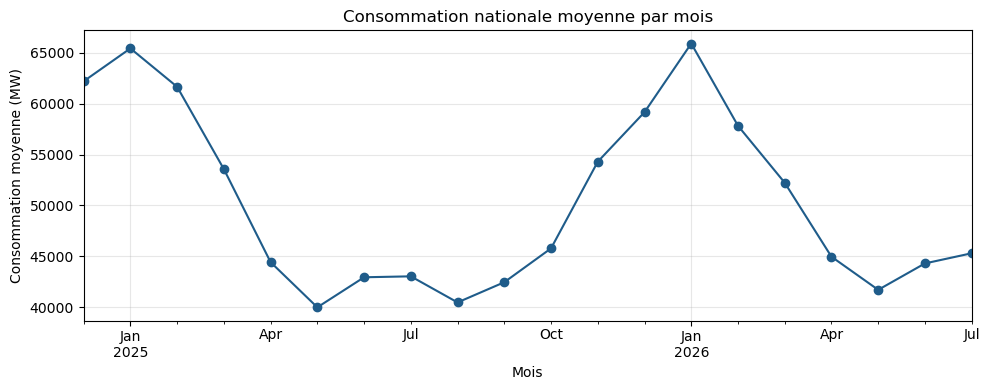

In [33]:
plt.figure(figsize=(10, 4))
monthly["mean"].plot(marker="o", color="#1F5C8A")
plt.title("Consommation nationale moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/figure1_evolution_mensuelle.png", dpi=150)
plt.show()

## 12. Top 10 des pics historiques (section 4.2)

In [34]:
df_final.nlargest(10, "consommation_mw")[["date_heure", "consommation_mw"]]

,date_heure,consommation_mw
8913,2026-01-07 08:00:00+00:00,88243.785714
8914,2026-01-07 09:00:00+00:00,88073.571429
8915,2026-01-07 10:00:00+00:00,87447.214286
8875,2026-01-05 18:00:00+00:00,87435.785714
8916,2026-01-07 11:00:00+00:00,87277.214286
8912,2026-01-07 07:00:00+00:00,87238.714286
8866,2026-01-05 09:00:00+00:00,86748.642857
8865,2026-01-05 08:00:00+00:00,86709.500000
8923,2026-01-07 18:00:00+00:00,86159.500000
8867,2026-01-05 10:00:00+00:00,86090.285714


## 13. Répartition régionale (sections 4.3 / 5.3)

In [35]:
df_reg_moy = (
    df_regions.groupby("region")["consommation_mw"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)
df_reg_moy

region
Île-de-France                 7563.0
Auvergne-Rhône-Alpes          7212.0
Hauts-de-France               5402.0
Grand Est                     4847.0
Nouvelle-Aquitaine            4735.0
Provence-Alpes-Côte d'Azur    4428.0
Occitanie                     4194.0
Normandie                     2970.0
Pays de la Loire              2929.0
Bretagne                      2503.0
Bourgogne-Franche-Comté       2250.0
Centre-Val de Loire           2055.0
Name: consommation_mw, dtype: float64

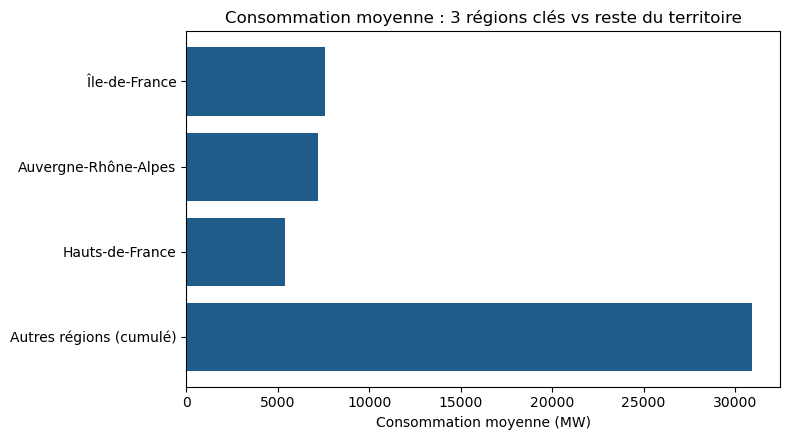

Part des 3 régions clés : 39.5 %


In [36]:
top3 = df_reg_moy.head(3)
autres = df_reg_moy.iloc[3:].sum()
plot_series = pd.concat([top3, pd.Series({"Autres régions (cumulé)": autres})])

plt.figure(figsize=(8, 4.5))
plt.barh(plot_series.index, plot_series.values, color="#1F5C8A")
plt.xlabel("Consommation moyenne (MW)")
plt.title("Consommation moyenne : 3 régions clés vs reste du territoire")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/figure2_regions_cles.png", dpi=150)
plt.show()

part_top3_pct = 100 * top3.sum() / df_reg_moy.sum()
print(f"Part des 3 régions clés : {part_top3_pct:.1f} %")

## 14. Distribution et test hiver/été (sections 5.4 / 7.2)

In [37]:
def saison(mois: int) -> str:
    if mois in (12, 1, 2):
        return "hiver"
    if mois in (6, 7, 8):
        return "ete"
    return "intersaison"

df_final["saison"] = df_final["date_heure"].dt.month.map(saison)
hiver = df_final.loc[df_final["saison"] == "hiver", "consommation_mw"].dropna()
ete = df_final.loc[df_final["saison"] == "ete", "consommation_mw"].dropna()

print(f"Hiver : n={len(hiver)}, moyenne={hiver.mean():.0f} MW")
print(f"Été   : n={len(ete)}, moyenne={ete.mean():.0f} MW")

Hiver : n=3073, moyenne=62127 MW
Été   : n=3118, moyenne=43165 MW


In [38]:
t_stat, p_value = stats.ttest_ind(hiver, ete, equal_var=False)
print(f"t = {t_stat:.2f}, p-value = {p_value:.3e}")

t = 109.50, p-value = 0.000e+00


C:\Users\PC\AppData\Local\Temp\ipykernel_24828\4185080125.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hiver.values, ete.values], labels=["Hiver", "Été"], patch_artist=True,


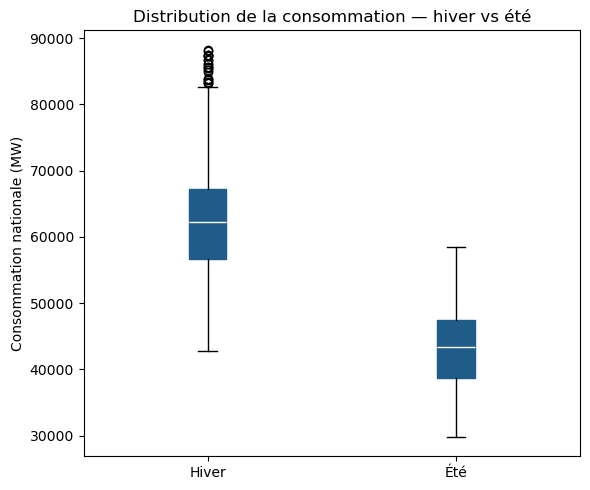

In [39]:
plt.figure(figsize=(6, 5))
plt.boxplot([hiver.values, ete.values], labels=["Hiver", "Été"], patch_artist=True,
            boxprops=dict(facecolor="#1F5C8A", color="#1F5C8A"),
            medianprops=dict(color="white"))
plt.ylabel("Consommation nationale (MW)")
plt.title("Distribution de la consommation — hiver vs été")
plt.tight_layout()
plt.savefig("figures/figure3_dispersion_hiver_ete.png", dpi=150)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_24828\1985315933.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hiver.values, ete.values], labels=["Hiver", "Été"], patch_artist=True,


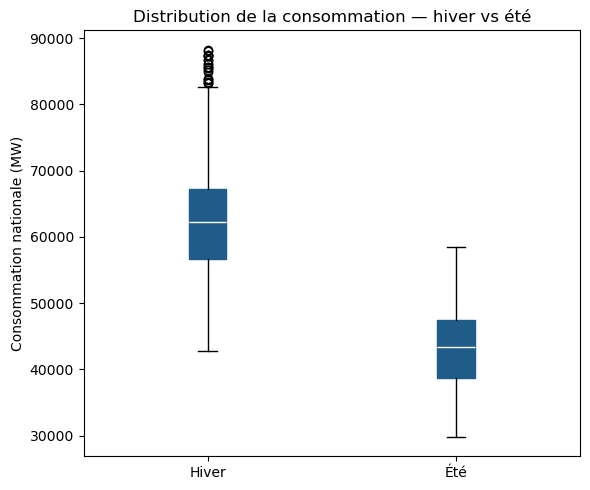

In [45]:
plt.figure(figsize=(6, 5))
plt.boxplot([hiver.values, ete.values], labels=["Hiver", "Été"], patch_artist=True,
            boxprops=dict(facecolor="#1F5C8A", color="#1F5C8A"),
            medianprops=dict(color="white"))
plt.ylabel("Consommation nationale (MW)")
plt.title("Distribution de la consommation — hiver vs été")
plt.tight_layout()
plt.savefig("figures/figure3_dispersion_hiver_ete.png", dpi=150)
plt.show()


In [46]:
hiver = df_final.loc[df_final["saison"] == "hiver", "consommation_mw"].dropna()
ete = df_final.loc[df_final["saison"] == "ete", "consommation_mw"].dropna()

t_stat, p_value = stats.ttest_ind(hiver, ete, equal_var=False)

resultats_saison = pd.DataFrame({
    "n": [len(hiver), len(ete)],
    "Consommation moyenne (MW)": [round(hiver.mean()), round(ete.mean())]
}, index=["Hiver (déc.-janv.-fév.)", "Été (juin-juil.-août)"])

print(f"t = {t_stat:.2f}, p-value = {p_value:.3e}")
resultats_saison

t = 109.50, p-value = 0.000e+00


,n,Consommation moyenne (MW)
Hiver (déc.-janv.-fév.),3073,62127
Été (juin-juil.-août),3118,43165


## 15. Corrélation température / consommation (section 7.1)

In [40]:
df_corr = df_final.dropna(subset=["consommation_mw", "temperature_c"])
r, p_value_temp = stats.pearsonr(df_corr["temperature_c"], df_corr["consommation_mw"])
print(f"n = {len(df_corr)}, r = {r:.3f}, p-value = {p_value_temp:.3e}")

n = 11853, r = -0.558, p-value = 0.000e+00


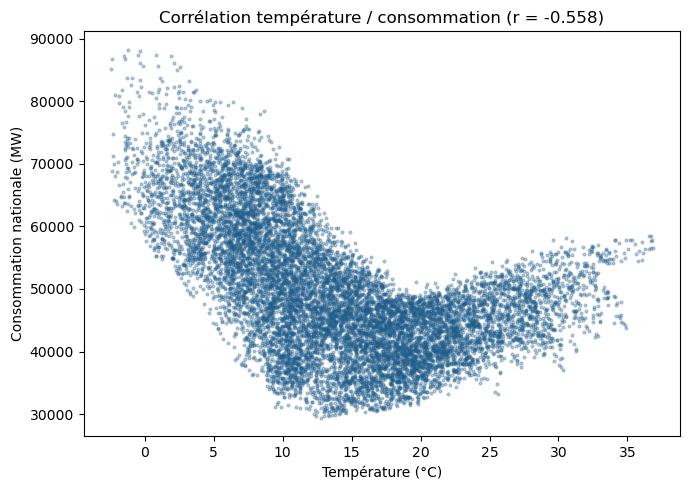

In [41]:
plt.figure(figsize=(7, 5))
plt.scatter(df_corr["temperature_c"], df_corr["consommation_mw"], s=4, alpha=0.3, color="#1F5C8A")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation nationale (MW)")
plt.title(f"Corrélation température / consommation (r = {r:.3f})")
plt.tight_layout()
plt.savefig("figures/figure4_correlation_temperature.png", dpi=150)
plt.show()